<a href="https://colab.research.google.com/github/Akanshajoshiiii/NLP_LAB/blob/main/lab3_nlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

hyper parameter tuning

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential,layers
from tensorflow.keras.datasets import mnist

In [2]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 1.6 MB/s eta 0:00:00


In [3]:
from keras_tuner import RandomSearch

In [4]:
(x_train,y_train),(x_test,y_test)=mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
x_train.shape

(60000, 28, 28)

Images ko neural network ke liye ready karne ke liye:
- `reshape(-1, 784)` → 28×28 image ko 1D vector me convert karta hai  
- `/255.0` → pixel values (0–255) ko
normalize karke 0–1 range me lata hai


In [6]:
x_train=x_train.reshape(-1,784)/255.0
x_test=x_test.reshape(-1,784)/255.0

Input → Hidden layer 1 → Hidden layer 2 → Output

hp.Int('unit1', 32 → 128, step=32)
Possible values:

32, 64, 96, 128

hp.Choice('act1', ['relu', 'sigmoid', 'tanh'])

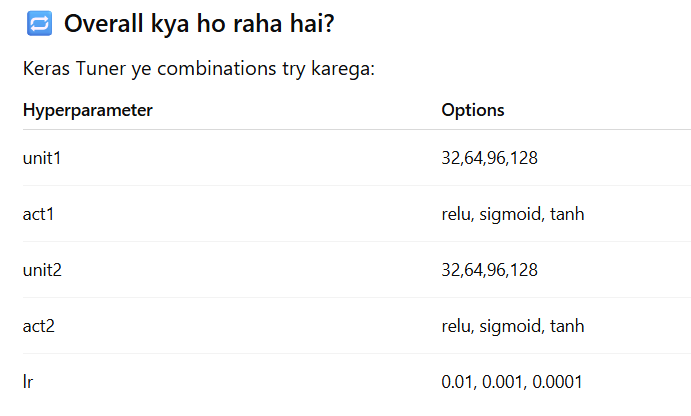

In [7]:
from tensorflow import keras
from tensorflow.keras import layers, Sequential

#Ye function Keras Tuner ke liye likha gaya hai
#hp = HyperParameters object
#Iska kaam hai different combinations try karna (units, activation, learning rate)

def build_model(hp):
    model = Sequential([
        # Hidden layer 1
        #unit=neurons
        layers.Dense(
            units=hp.Int('unit1', min_value=32, max_value=128, step=32),
            activation=hp.Choice('act1', ['relu', 'sigmoid', 'tanh'])
        ),

        # Hidden layer 2
        layers.Dense(
            units=hp.Int('unit2', min_value=32, max_value=128, step=32),
            activation=hp.Choice('act2', ['relu', 'sigmoid', 'tanh'])
        ),

        # Output layer
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=hp.Choice('lr', [0.01, 0.001, 0.0001])
        ),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


➡ Tuner ka goal kya hai?

👉 Validation loss ko minimum karna

Matlab:

training ke baad

validation data pe

jis model ka loss sabse kam, wahi best

📌 Agar likhte:

objective='val_accuracy',to tuner accuracy maximize karta

In [8]:
#directory p iske res store honge , pehleke 4 agle k 3
#random se gridsearch ki trf jata

#Randomly kuch combinations uthata hai

#trials=5 :Sirf 5 different hyperparameter combinations
tuner=RandomSearch(build_model,objective='val_loss',max_trials=5,directory='/mydir8')

In [10]:
# ye print karta hai ki tuner kis-kis hyperparameter ko tune karega

tuner.search_space_summary()

Search space summary
Default search space size: 5
unit1 (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 128, 'step': 32, 'sampling': 'linear'}
act1 (Choice)
{'default': 'relu', 'conditions': [], 'values': ['relu', 'sigmoid', 'tanh'], 'ordered': False}
unit2 (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 128, 'step': 32, 'sampling': 'linear'}
act2 (Choice)
{'default': 'relu', 'conditions': [], 'values': ['relu', 'sigmoid', 'tanh'], 'ordered': False}
lr (Choice)
{'default': 0.01, 'conditions': [], 'values': [0.01, 0.001, 0.0001], 'ordered': True}


In [ ]:
tuner.search(x_train,y_train,validation_data=(x_test,y_test),epochs=5)

Trial 5 Complete [00h 00m 35s]
val_loss: 0.09275104850530624

Best val_loss So Far: 0.0793817937374115
Total elapsed time: 00h 02m 48s


Hyperparameter tuning start karti hai

alag-alag models banenge

har model train hoga

validation loss check hoga

best hyperparameters choose honge,Validation data

training ke baad performance check hoti hai

objective = val_loss isi data pe calculate hota hai

In [ ]:
tuner.results_summary()

Results summary
Results in /mydir8/untitled_project
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 1 summary
Hyperparameters:
unit1: 96
act1: tanh
unit2: 96
act2: tanh
lr: 0.001
Score: 0.0793817937374115

Trial 4 summary
Hyperparameters:
unit1: 64
act1: sigmoid
unit2: 96
act2: relu
lr: 0.001
Score: 0.09275104850530624

Trial 2 summary
Hyperparameters:
unit1: 32
act1: sigmoid
unit2: 64
act2: sigmoid
lr: 0.001
Score: 0.13909812271595

Trial 0 summary
Hyperparameters:
unit1: 128
act1: relu
unit2: 64
act2: tanh
lr: 0.01
Score: 0.19147592782974243

Trial 3 summary
Hyperparameters:
unit1: 64
act1: sigmoid
unit2: 32
act2: sigmoid
lr: 0.0001
Score: 0.3778998553752899


In [ ]:
#setting number of layers as hyper parameter


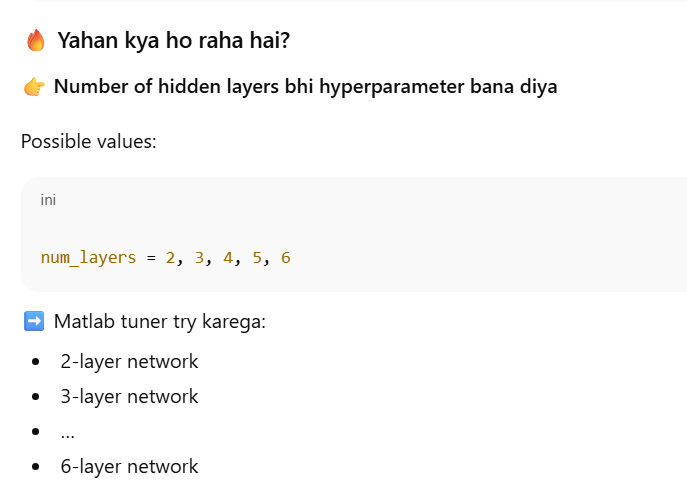

'unit0', 'unit1', 'unit2', ...
Possible values:

32, 64, 96, 128

🧠Example (agar num_layers = 3)

Activation
'act0', 'act1', 'act2', ...


Options:

relu / tanh / sigmoid
Model banega:

Dense(unit0, act0)
Dense(unit1, act1)
Dense(unit2, act2)

In [ ]:
from keras import Optimizer
def build_model1(hp):
  model=Sequential()
  for i in range(hp.Int('num_layers',min_value=2,max_value=6,step=1)):

    model.add(layers.Dense(units=hp.Int('unit'+str(i),min_value=32,max_value=128,step=32),activation=hp.Choice('act'+str(i),['relu','tanh','sigmoid']))) #layers add krre , no of layers ko bhi ek hpm bna diya
  model.add(layers.Dense(10,activation='softmax')) #output layer
  model.compile(optimizer=keras.optimizers.Adam(learning_rate=hp.Choice('lr',[0.1,0.01,0.001,0.0001])),loss=keras.losses.sparse_categorical_crossentropy,metrics=['accuracy'])
  return model

In [ ]:
tuner1=RandomSearch(build_model1,max_trials=5,objective='val_loss',directory='/mydir9')

#########epoch as a parameter in assignment


In [ ]:
tuner1.search(x_train,y_train,validation_data=(x_test,y_test),epochs=5)

Trial 5 Complete [00h 00m 31s]
val_loss: 0.18866586685180664

Best val_loss So Far: 0.09506025910377502
Total elapsed time: 00h 02m 52s


In [ ]:
#cnn ##padding same , valid se shape reduce hoti but minus m shape na chli jaye so

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

class CNNBlock(layers.Layer):

    def __init__(self, num_filters, kernel_size=3):
        super().__init__()

        self.convolution = layers.Conv2D(
            num_filters,
            kernel_size,
            padding='same'
        )  # same padding → spatial size reduce nahi hota

        self.normalization = layers.BatchNormalization()
        self.pooling = layers.MaxPooling2D()

    def call(self, inputs):
        x = self.convolution(inputs)
        x = self.normalization(x)
        x = keras.activations.relu(x)
        x = self.pooling(x)
        return x


In [ ]:
def build_model2(hp):
  model=Sequential()
  for i in range(hp.Int('num_cnnblock',min_value=2,max_value=6,step=1)):
     model.add(CNNBlock(hp.Int('num_filters',min_value=32,max_value=1024,step=32)))
  model.add(layers.Flatten())
  model.add(layers.Dense(units=hp.Int('unit1',min_value=32,max_value=128,step=32),activation=hp.Choice('act1',['relu','tanh','sigmoid'])))
  model.add(layers.Dense(10,activation='softmax'))

  model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.01),loss=keras.losses.SparseCategoricalCrossentropy(),metrics=['accuracy'])
  return model

In [ ]:
(x_train,y_train),(x_test,y_test)=mnist.load_data()
x_train=x_train.reshape(-1,28,28,1)/255.0
x_test=x_test.reshape(-1,28,28,1)/255.0
tuner3=RandomSearch(build_model2,max_trials=5,objective='val_loss',directory='/mydir11')

custum callback=training,testing,validation

In [ ]:
tuner3.search(x_train,y_train,validation_data=(x_test,y_test),epochs=5)

Trial 5 Complete [00h 00m 02s]

Best val_loss So Far: 0.034656550735235214
Total elapsed time: 00h 06m 21s


saved model to use krte , to direst traing m age use krskte. agr wts save krre to same architecture ka model define krna hoga along with itts compilation parameters


In [ ]:
model=Sequential([
    CNNBlock(64),CNNBlock(128),CNNBlock(256),layers.Flatten(),
    layers.Dense(10,activation='softmax')
])

In [ ]:
model.compile(optimizer=keras.optimizers.Adam(),
              loss=keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

In [ ]:
checkpoint=keras.callbacks.ModelCheckpoint('myder12/best.keras',
                                monitor='val_loss',
                                mode='auto',
                                save_weights_only=False,
                                save_best_only=True) #max,min dekho

In [ ]:
#koi chis monitor krni h , if consicutively loss badhra to

In [ ]:
earlystop=keras.callbacks.EarlyStopping(monitor='val_loss',
                              mode='min',
                              patience=3,
                              verbose=1,
                              min_delta=0.05,

                              )

validation data dena zaruri coz hme val_loss ko hi check krna h

In [ ]:
model.fit(x_train,y_train,validation_data=(x_test,y_test),verbose=1,batch_size=64,epochs=10,callbacks=[checkpoint,earlystop])

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.9313 - loss: 0.2848 - val_accuracy: 0.9849 - val_loss: 0.0516
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9878 - loss: 0.0389 - val_accuracy: 0.9782 - val_loss: 0.0705
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9893 - loss: 0.0328 - val_accuracy: 0.9870 - val_loss: 0.0432
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9928 - loss: 0.0220 - val_accuracy: 0.9846 - val_loss: 0.0495
Epoch 4: early stopping


In [ ]:
reducelr=keras.callbacks.ReduceLROnPlateau(monitor='val_loss',
                                  mode='min',
                                  patience=3,
                                  min_delta=0.5,
                                  factor=0.1,
                                  cooldown=0,
                                           verbose=1) #kitni epochs k liye monitor krna chod de

In [ ]:
model.fit(x_train,y_train,validation_data=(x_test,y_test),verbose=1,batch_size=64,epochs=10,callbacks=[checkpoint,reducelr])

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9947 - loss: 0.0169 - val_accuracy: 0.9920 - val_loss: 0.0253 - learning_rate: 0.0010
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9965 - loss: 0.0109 - val_accuracy: 0.9860 - val_loss: 0.0532 - learning_rate: 0.0010
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9961 - loss: 0.0117 - val_accuracy: 0.9905 - val_loss: 0.0311 - learning_rate: 0.0010
Epoch 4/10
932/938 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9973 - loss: 0.0086
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9972 - loss: 0.0086 - val_accuracy: 0.9911 - val_loss: 0.0336 - learning_rate: 0.0010
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9983 - loss: 0.0052 - val_accuracy: 0.9954 - val_loss: 0.0193 - learning_rate: 1.0000e-04
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9998 - loss: 0.001